# Portfolio Return Analysis & Benchmark Comparison
# Python for Finance: Investment Fundamentals & Data Analytics

## Python & Financial Data | 2015 - 2024

---

**Author:** Angelos Kesidis
**Target Firms:** JPMorgan Chase · Goldman Sachs · BlackRock  
**Period:** 2015-01-01 → 2024-01-01
**Date:** June 2026  
**Tools:** Python · NumPy · Pandas · Matplotlib · yfinance

---

## Portfolio Backtesting & Benchmark Comparison

This project evaluates the 2015–2024 historical performance of an equally weighted versus a custom-weighted portfolio of five diversified stocks against the S&P 500 and NASDAQ indices. Before coding, you must import the necessary libraries (e.g., yfinance, pandas) and globally define your asset tickers, timeframe parameters, and weight distributions. The script will then fetch the adjusted closing prices, calculate daily returns, and apply the portfolio weights to conduct the comparative analysis.

1. Stocks: AAPL, MSFT, JPM, JNJ, XOM (5 different sectors — tech, finance, healthcare, energy)
2. Period: 2015-01-01 to 2024-01-01
3. Portfolio 1: Equal weights (20% each)
4. Portfolio 2: [0.35, 0.25, 0.20, 0.10, 0.10]
5. Benchmarks: ^GSPC (S&P 500) and ^IXIC (NASDAQ)

# Workflow:
1. Data Collection & Diagnostics
2. Normalization & Visual Comparison
3. Log Returns  (time-series analysis — additive, approx. normal)
4. Annualized Returns per Stock
5. Portfolio Construction & Benchmark Comparison
6. Final Summary Table

#   Return Methodology:
• Log returns are used throughout for both individual stocks and benchmarks.They are time-additive, approximately normally distributed, and symmetric — the standard choice for time-series performance analysis.

• Formula: r_t = ln(P_t / P_{t-1})

• Annualization: R_annual = mean(r_daily) × 250


In [1]:
# ── IMPORTS ───────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
 
# ── GLOBAL PARAMETERS ─────────────────────────────────────────────────────────
STOCKS      = ["AAPL", "MSFT", "JPM", "JNJ", "XOM"]
BENCHMARKS  = ["^GSPC", "^IXIC"]
ASSETS      = STOCKS + BENCHMARKS
 
START        = "2015-01-01"
END          = "2024-01-01"
TRADING_DAYS = 250          # industry-standard annualisation factor
 
# Portfolio weights — must sum to 1.0
WEIGHTS_A = np.array([0.20, 0.20, 0.20, 0.20, 0.20])   # equal weight
WEIGHTS_B = np.array([0.35, 0.25, 0.20, 0.10, 0.10])   # conviction weight
 
# ── WEIGHT VALIDATION ─────────────────────────────────────────────────────────
assert abs(WEIGHTS_A.sum() - 1.0) < 1e-9, "Portfolio A weights do not sum to 1.0!"
assert abs(WEIGHTS_B.sum() - 1.0) < 1e-9, "Portfolio B weights do not sum to 1.0!"

# Section 1 — Data Collection & Portfolio Setup
We download adjusted closing prices for five large-cap U.S. equities across four distinct sectors, plus the S&P 500 and NASDAQ as our market benchmarks.

| Ticker | Company | Sector |
|--------|---------|--------|
| AAPL | Apple Inc. | Technology |
| MSFT | Microsoft Corp. | Technology |
| JPM | JPMorgan Chase | Financials |
| JNJ | Johnson & Johnson | Healthcare |
| XOM | Exxon Mobil | Energy |
| ^GSPC | S&P 500 | Benchmark |
| ^IXIC | NASDAQ | Benchmark |

**Period:** 2015-01-01 → 2024-01-01

Portfolio 1: Equal weights (20% each)

Portfolio 2: Custom weights [0.35, 0.25, 0.20, 0.10, 0.10]

Adjusted closing prices account for dividends and stock splits — the correct input for return calculations.

In [2]:
# =============================================================================
# SECTION 1 — Data Collection & Diagnostics
# =============================================================================
print("=" * 65)
print("  SECTION 1 — Data Collection & Diagnostics")
print("=" * 65)
 
data = yf.download(ASSETS, start=START, end=END, auto_adjust=True)["Close"]
 
# Forward-fill gaps (e.g. public holidays), then drop any remaining NaNs
data = data.ffill().dropna()
 
print(f"  Shape      : {data.shape[0]} rows × {data.shape[1]} columns")
print(f"  Date range : {data.index[0].date()} → {data.index[-1].date()}")
print(f"  Columns    : {list(data.columns)}")
print()
print("  Missing values per column:")
print(data.isnull().sum().to_string())
print()
print("  First 5 rows:")
print(data.head().to_string())
print()
print("  Last 5 rows:")
print(data.tail().to_string())

# ── Handle missing values ─────────────────────────────────────────────────
# Forward-fill first (carry last known price), then drop any remaining NaNs
data = data.ffill().dropna()

print(f"Clean dataset shape: {data.shape}")
print("No missing values." if data.isnull().sum().sum() == 0 else "Warning: NaNs remain!")

  SECTION 1 — Data Collection & Diagnostics


[*********************100%***********************]  7 of 7 completed

  Shape      : 2264 rows × 7 columns
  Date range : 2015-01-02 → 2023-12-29
  Columns    : ['AAPL', 'JNJ', 'JPM', 'MSFT', 'XOM', '^GSPC', '^IXIC']

  Missing values per column:
Ticker
AAPL     0
JNJ      0
JPM      0
MSFT     0
XOM      0
^GSPC    0
^IXIC    0

  First 5 rows:
Ticker           AAPL        JNJ        JPM       MSFT        XOM        ^GSPC        ^IXIC
Date                                                                                       
2015-01-02  24.192608  76.110878  46.274315  39.681740  57.145542  2058.199951  4726.810059
2015-01-05  23.511061  75.579330  44.837730  39.316841  55.581951  2020.579956  4652.569824
2015-01-06  23.513271  75.207954  43.675140  38.739777  55.286446  2002.609985  4592.740234
2015-01-07  23.842981  76.868225  43.741772  39.231972  55.846642  2025.900024  4650.470215
2015-01-08  24.759083  77.472618  44.719250  40.386093  56.776196  2062.139893  4736.189941

  Last 5 rows:
Ticker            AAPL         JNJ         JPM        MSFT    

# Section 2 — Normalization & Visual Comparison
Raw price levels are not directly comparable across stocks. We normalize all series to base 100 on the first trading day, so the y-axis reads as "cumulative % gain from Jan 2015."$$P_{\text{norm},t} = \frac{P_t}{P_0} \times 100$$

Two charts are produced:

Chart A: The five stocks only — to identify relative winners within the portfolio.

Chart B: All five stocks + S&P 500 and NASDAQ benchmarks — to assess alpha generation.

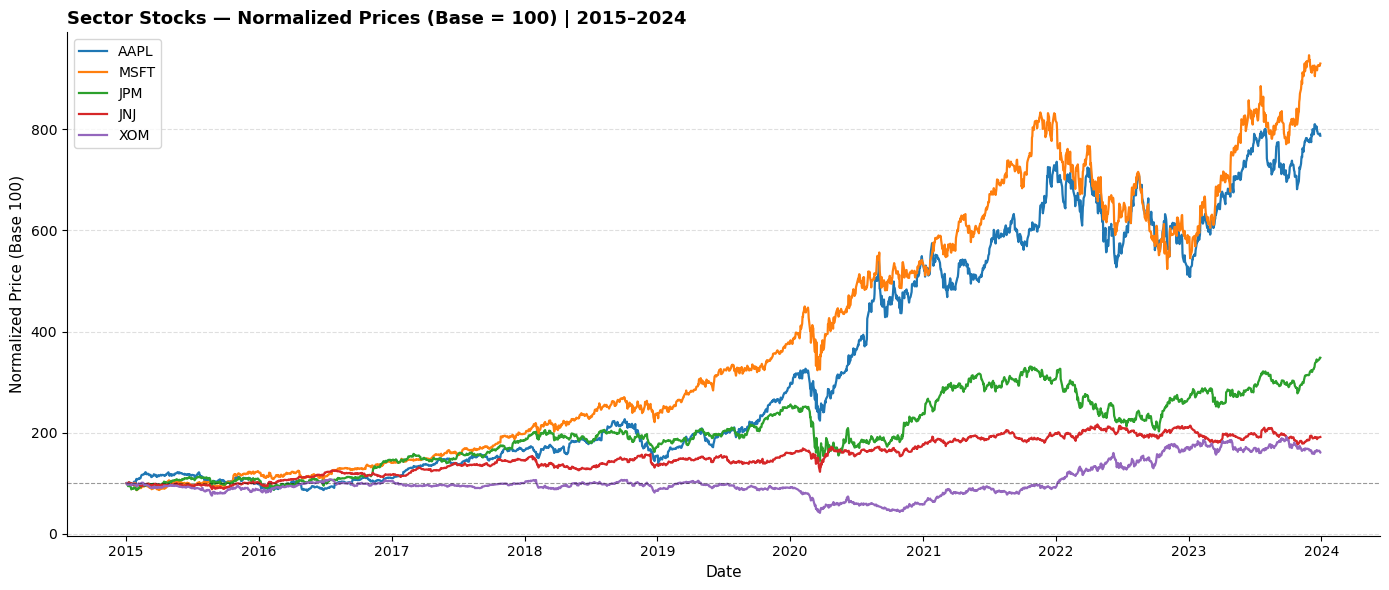

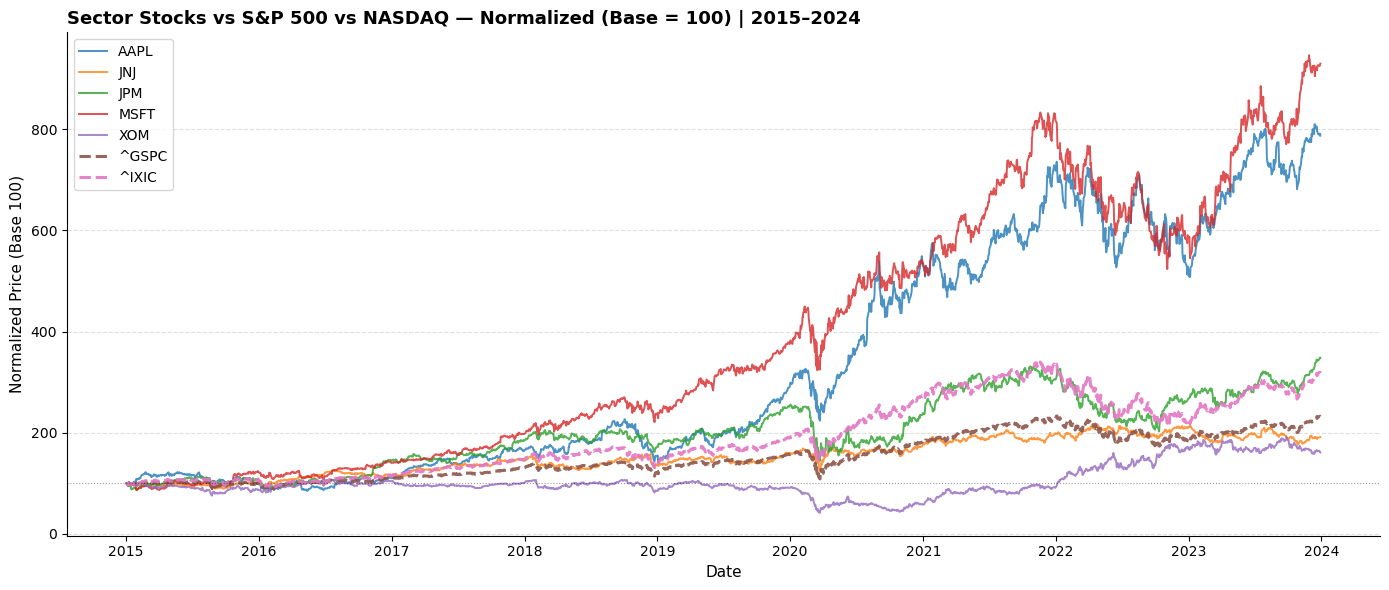

In [3]:
# ============================================================
# SECTION 2 — Normalization & Visual Comparison
# ============================================================

# ── Chart A: Sector stocks only ───────────────────────────────────────────────
normalized_stocks = (data[STOCKS] / data[STOCKS].iloc[0]) * 100
 
fig, ax = plt.subplots(figsize=(14, 6))
for col in normalized_stocks.columns:
    ax.plot(normalized_stocks[col], label=col, linewidth=1.6)
 
ax.axhline(100, color="black", linewidth=0.8, linestyle="--", alpha=0.4)
ax.set_title("Sector Stocks — Normalized Prices (Base = 100) | 2015–2024",
             fontsize=13, fontweight="bold", loc="left")
ax.set_xlabel("Date", fontsize=11)
ax.set_ylabel("Normalized Price (Base 100)", fontsize=11)
ax.legend(loc="upper left", fontsize=10)
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()
 
# ── Chart B: Stocks + benchmarks ──────────────────────────────────────────────
normalized_all = (data / data.iloc[0]) * 100
 
fig, ax = plt.subplots(figsize=(14, 6))
for col in normalized_all.columns:
    if col in BENCHMARKS:
        ax.plot(normalized_all[col], label=col, linewidth=2.2,
                linestyle="--", alpha=0.9)
    else:
        ax.plot(normalized_all[col], label=col, linewidth=1.4, alpha=0.8)
 
ax.axhline(100, color="black", linewidth=0.8, linestyle=":", alpha=0.4)
ax.set_title("Sector Stocks vs S&P 500 vs NASDAQ — Normalized (Base = 100) | 2015–2024",
             fontsize=13, fontweight="bold", loc="left")
ax.set_xlabel("Date", fontsize=11)
ax.set_ylabel("Normalized Price (Base 100)", fontsize=11)
ax.legend(loc="upper left", fontsize=10)
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

---
## Section 3 — Log Returns
We compute log returns for our time-series analysis, as they offer distinct mathematical advantages when evaluating performance over multiple periods.

| Method | Formula | Best used when |
|--------|---------|----------------|
| Log Return | $\ln(P_t / P_{t-1})$ | Single asset, multiple periods |

**Why log returns here?**

-**Time-additive:** multi-period log return = sum of single-period log returns

-**Approximate normality:** better statistical properties for regression & risk models

-**Symmetric:** equal magnitude for +x% and -x% moves


  SECTION 3 — Log Returns (first 5 rows)
Ticker          AAPL       JNJ       JPM      MSFT       XOM     ^GSPC     ^IXIC
Date                                                                            
2015-01-05 -0.028576 -0.007008 -0.031537 -0.009238 -0.027743 -0.018447 -0.015831
2015-01-06  0.000094 -0.004926 -0.026271 -0.014786 -0.005331 -0.008933 -0.012943
2015-01-07  0.013925  0.021836  0.001524  0.012625  0.010082  0.011563  0.012491
2015-01-08  0.037703  0.007832  0.022101  0.028993  0.016508  0.017730  0.018265
2015-01-09  0.001072 -0.013723 -0.017540 -0.008440 -0.001410 -0.008439 -0.006805


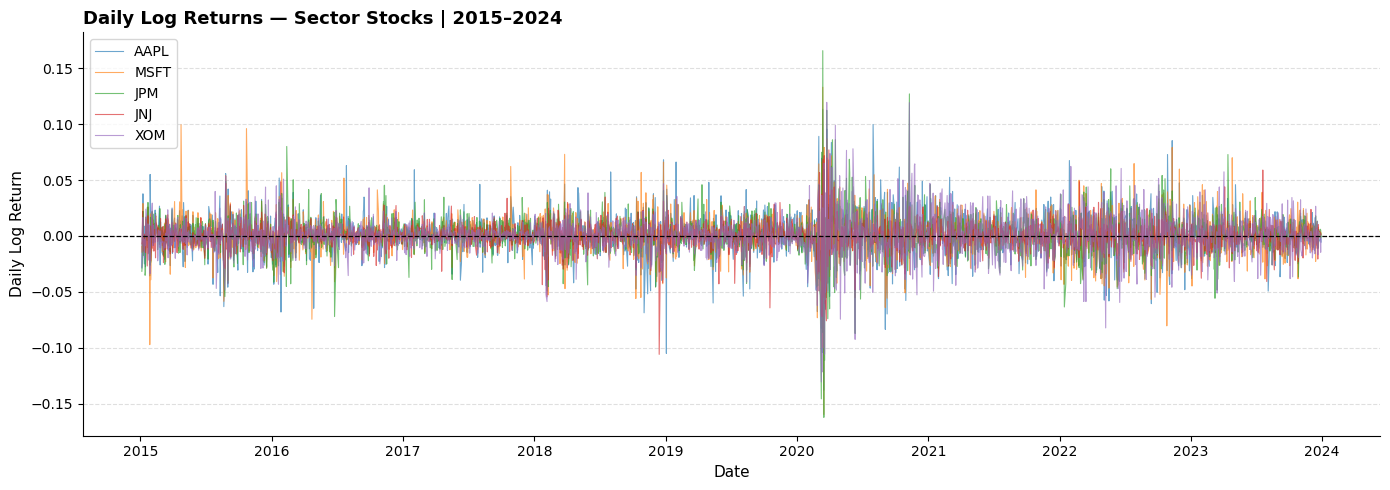

In [4]:
# ============================================================
# SECTION 3 — Log Returns
# ============================================================

log_returns = np.log(data / data.shift(1)).dropna()
 
print("\n" + "=" * 65)
print("  SECTION 3 — Log Returns (first 5 rows)")
print("=" * 65)
print(log_returns.head().to_string())
 
# ── Plot: Daily log returns — stocks only ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))
for col in STOCKS:
    ax.plot(log_returns[col], label=col, alpha=0.65, linewidth=0.8)
 
ax.axhline(0, color="black", linewidth=0.9, linestyle="--")
ax.set_title("Daily Log Returns — Sector Stocks | 2015–2024",
             fontsize=13, fontweight="bold", loc="left")
ax.set_xlabel("Date", fontsize=11)
ax.set_ylabel("Daily Log Return", fontsize=11)
ax.legend(loc="upper left", fontsize=10)
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

# Section 4 - Annualized Returns per Stock
Daily mean log returns are scaled to an annual figure using the standard convention of 250 trading days per year (U.S. equity markets are open $\approx$ 252 days, but 250 is the established industry convention).$$R_{\text{annual}} = \bar{r}_{\text{daily}} \times 250$$

Results are ranked from highest to lowest to quickly identify the top performer.


  SECTOR STOCKS — ANNUALIZED LOG RETURNS
  Ticker   | Annual Return (%)
  ----------------------------
  MSFT     |            24.63%
  AAPL     |            22.79%
  JPM      |            13.78%
  JNJ      |             7.18%
  XOM      |             5.26%
  ----------------------------
  Top performer  : MSFT  (24.63%)
  Worst performer: XOM  (5.26%)


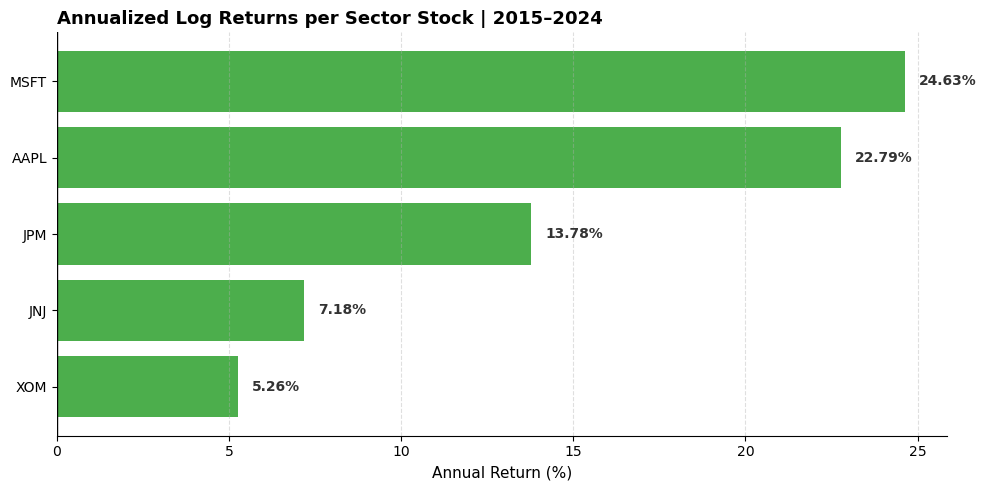

In [5]:
# ============================================================
# SECTION 4 — Annualized Returns per Stock
# ============================================================

annual_log_returns = log_returns[STOCKS].mean() * TRADING_DAYS
 
summary = (
    pd.DataFrame({"Annual Return (%)": (annual_log_returns * 100).round(2)})
    .sort_values("Annual Return (%)", ascending=False)
)
 
best  = summary.index[0]
worst = summary.index[-1]
 
print("\n" + "=" * 50)
print("  SECTOR STOCKS — ANNUALIZED LOG RETURNS")
print("=" * 50)
print(f"  {'Ticker':<8} | {'Annual Return (%)':>17}")
print("  " + "-" * 28)
for ticker, row in summary.iterrows():
    print(f"  {ticker:<8} | {row['Annual Return (%)']:>16.2f}%")
print("  " + "-" * 28)
print(f"  Top performer  : {best}  ({summary.loc[best,  'Annual Return (%)']:.2f}%)")
print(f"  Worst performer: {worst}  ({summary.loc[worst, 'Annual Return (%)']:.2f}%)")
print("=" * 50)
 
# ── Horizontal bar chart ──────────────────────────────────────────────────────
summary_asc = summary.sort_values("Annual Return (%)", ascending=True)
bar_colors  = ["#d62728" if v < 0 else "#2ca02c"
               for v in summary_asc["Annual Return (%)"]]
 
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(summary_asc.index, summary_asc["Annual Return (%)"],
               color=bar_colors, alpha=0.85, edgecolor="none")
 
for bar in bars:
    w  = bar.get_width()
    x  = w + 0.4 if w >= 0 else w - 0.4
    ha = "left" if w >= 0 else "right"
    ax.text(x, bar.get_y() + bar.get_height() / 2,
            f"{w:.2f}%", va="center", ha=ha,
            fontsize=10, fontweight="bold", color="#333333")
 
ax.axvline(0, color="black", linewidth=1.0)
ax.set_title("Annualized Log Returns per Sector Stock | 2015–2024",
             fontsize=13, fontweight="bold", loc="left")
ax.set_xlabel("Annual Return (%)", fontsize=11)
ax.grid(axis="x", linestyle="--", alpha=0.4)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
plt.tight_layout()
plt.show()

---
## Section 5 — Portfolio Construction & Benchmark Comparison
Two portfolios are constructed and compared against the S&P 500 and NASDAQ benchmarks:

**Portfolio 1 — Equal Weight (passive baseline)**

- Each stock receives 1/5 = 20% of capital
- Rationale: eliminates subjective bias; useful as a passive baseline

**Portfolio 2 — Custom Weight (conviction-based)**

- Overweight AAPL (35%) and MSFT (25%): the technology sector showed the strongest secular growth over the 2015–2024 period (cloud computing, ecosystem expansion, enterprise software).
- Neutral weight JPM (20%): maintains standard exposure to financials, sensitive to the interest rate environment.
- Underweight JNJ (10%) and XOM (10%): defensive healthcare and energy positions utilized for drawdown protection and portfolio diversification.

| Stock | Portfolio 1 | Portfolio 2 | Rationale (Portfolio 2) |
|-------|-------------|-------------|---------------|
| AAPL | 20% | 35% | Technology: High historical return; iPhone ecosystem & services growth |
| MSFT | 20% | 25% | Technology: Secular tailwinds in Cloud (Azure) & software |
| JPM | 20% | 20% | Financials: Rate sensitivity; steady performance |
| JNJ | 20% | 10% | Healthcare: Defensive position; lower volatility |
| ΧΟΜ | 20% | 10% | Energy: Diversification; inflation protection |

> *Portfolio return = weighted sum of individual annualized returns (dot product)*
> $$R_p = \sum_{i=1}^{n} w_i \cdot R_i = \mathbf{w}^T \mathbf{R}$$


  SECTION 5 — PORTFOLIO vs BENCHMARK COMPARISON
  Strategy / Benchmark           |   Return |  α vs S&P |  α vs NDX
  -----------------------------------------------------------------
  Portfolio A — Equal Weight     |   14.73% |    +5.44% |    +1.96%
  Portfolio B — Conviction       |   18.14% |    +8.85% |    +5.37%
  S&P 500 (^GSPC)                |    9.29% |         — |         —
  NASDAQ (^IXIC)                 |   12.77% |         — |         —


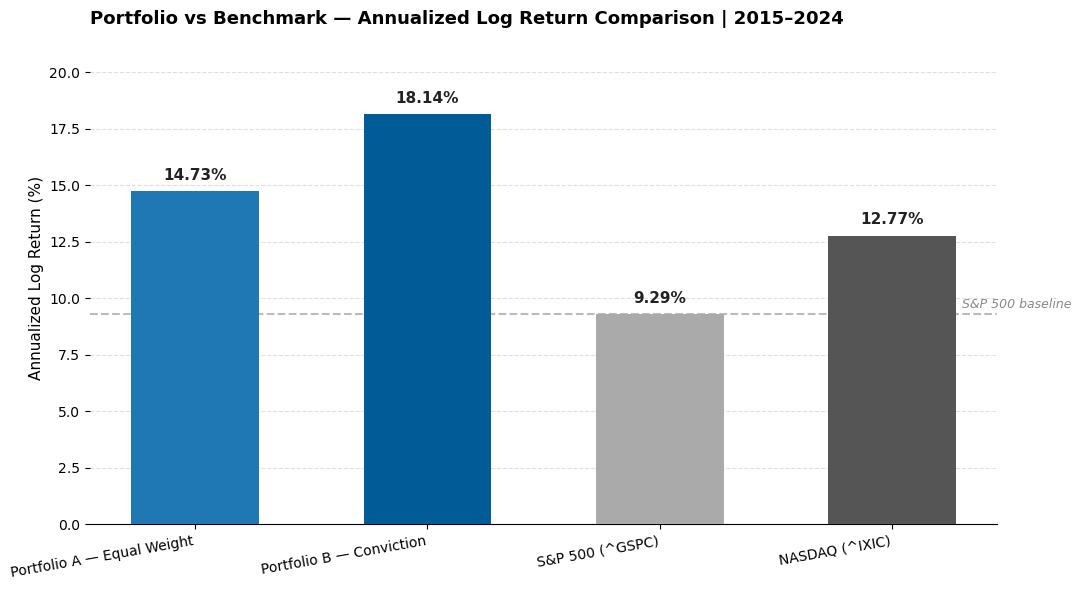

In [6]:
# ============================================================
# SECTION 5 — Portfolio Construction & Benchmark Comparison
# ============================================================

# Annualized log returns — stocks
annual_returns_stocks = log_returns[STOCKS].mean() * TRADING_DAYS
 
# Portfolio dot products (log returns → consistent with benchmark calculation)
port_a = np.dot(WEIGHTS_A, annual_returns_stocks)
port_b = np.dot(WEIGHTS_B, annual_returns_stocks)
 
# Benchmark annualized log returns
sp500_ret  = log_returns["^GSPC"].mean() * TRADING_DAYS
nasdaq_ret = log_returns["^IXIC"].mean() * TRADING_DAYS
 
# ── Comparison DataFrame ──────────────────────────────────────────────────────
labels = [
    "Portfolio A — Equal Weight",
    "Portfolio B — Conviction",
    "S&P 500 (^GSPC)",
    "NASDAQ (^IXIC)",
]
values = [port_a * 100, port_b * 100, sp500_ret * 100, nasdaq_ret * 100]
 
comp_df = pd.DataFrame({"Annual Return (%)": values}, index=labels)
 
# ── Console output ────────────────────────────────────────────────────────────
print("\n" + "=" * 65)
print("  SECTION 5 — PORTFOLIO vs BENCHMARK COMPARISON")
print("=" * 65)
print(f"  {'Strategy / Benchmark':<30} | {'Return':>8} | {'α vs S&P':>9} | {'α vs NDX':>9}")
print("  " + "-" * 65)
 
sp500_val  = comp_df.loc["S&P 500 (^GSPC)",  "Annual Return (%)"]
nasdaq_val = comp_df.loc["NASDAQ (^IXIC)",   "Annual Return (%)"]
 
for name, row in comp_df.iterrows():
    ret     = row["Annual Return (%)"]
    vs_sp   = ret - sp500_val
    vs_ndx  = ret - nasdaq_val
    sp_str  = f"{vs_sp:+.2f}%"  if "Portfolio" in name else "   —"
    ndx_str = f"{vs_ndx:+.2f}%" if "Portfolio" in name else "   —"
    print(f"  {name:<30} | {ret:>7.2f}% | {sp_str:>9} | {ndx_str:>9}")
 
print("=" * 65)
 
# ── Bar chart ─────────────────────────────────────────────────────────────────
palette = ["#1f77b4", "#005b96", "#aaaaaa", "#555555"]
 
fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.bar(comp_df.index, comp_df["Annual Return (%)"],
              color=palette, edgecolor="none", width=0.55, zorder=3)
 
ax.axhline(sp500_val, color="#aaaaaa", linestyle="--",
           linewidth=1.5, zorder=1, alpha=0.8)
ax.text(3.3, sp500_val + 0.3, "S&P 500 baseline",
        color="#888888", fontsize=9, fontstyle="italic")
 
for bar in bars:
    h = bar.get_height()
    ax.annotate(f"{h:.2f}%",
                xy=(bar.get_x() + bar.get_width() / 2, h),
                xytext=(0, 6), textcoords="offset points",
                ha="center", va="bottom",
                fontsize=11, fontweight="bold", color="#222222")
 
ax.set_title("Portfolio vs Benchmark — Annualized Log Return Comparison | 2015–2024",
             fontsize=13, fontweight="bold", loc="left")
ax.set_ylabel("Annualized Log Return (%)", fontsize=11)
ax.set_ylim(0, comp_df["Annual Return (%)"].max() * 1.20)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.grid(axis="y", linestyle="--", alpha=0.4, zorder=0)
plt.xticks(fontsize=10, rotation=10, ha="right")
plt.tight_layout()
plt.show()

In [7]:
# =============================================================================
# SECTION 6 — Final Summary Table
# =============================================================================
 
print("\n" + "=" * 65)
print("  FINAL SUMMARY — Key Metrics")
print("=" * 65)
print(f"  Analysis period  : {START} → {END}")
print(f"  Trading days/yr  : {TRADING_DAYS}")
print(f"  Assets analyzed  : {', '.join(STOCKS)}")
print(f"  Benchmarks       : S&P 500 (^GSPC), NASDAQ (^IXIC)")
print(f"  Return metric    : Log returns (consistent across all assets)")
print()
print(f"  {'Metric':<42} {'Value':>10}")
print("  " + "-" * 54)
print(f"  {'Portfolio A (Equal Weight) — Annual Return':<42} {port_a*100:>9.2f}%")
print(f"  {'Portfolio B (Conviction)   — Annual Return':<42} {port_b*100:>9.2f}%")
print(f"  {'S&P 500   — Annual Return':<42} {sp500_ret*100:>9.2f}%")
print(f"  {'NASDAQ    — Annual Return':<42} {nasdaq_ret*100:>9.2f}%")
print(f"  {'Portfolio B  α vs S&P 500':<42} {(port_b - sp500_ret)*100:>+9.2f}%")
print(f"  {'Portfolio B  α vs NASDAQ':<42} {(port_b - nasdaq_ret)*100:>+9.2f}%")
print(f"  {'Top stock (annualized log return)':<42} {best:>9}")
print(f"  {'Worst stock (annualized log return)':<42} {worst:>9}")
print("=" * 65)
print()
print("  Methodology note:")
print("  • Log returns used throughout — ensures consistent, like-for-like")
print("    comparison between individual stocks, portfolios, and benchmarks.")
print("  • Annualization: mean daily log return × 250 trading days.")
print("  • Portfolio return: dot product of weight vector and return vector.")
print("=" * 65)


  FINAL SUMMARY — Key Metrics
  Analysis period  : 2015-01-01 → 2024-01-01
  Trading days/yr  : 250
  Assets analyzed  : AAPL, MSFT, JPM, JNJ, XOM
  Benchmarks       : S&P 500 (^GSPC), NASDAQ (^IXIC)
  Return metric    : Log returns (consistent across all assets)

  Metric                                          Value
  ------------------------------------------------------
  Portfolio A (Equal Weight) — Annual Return     14.73%
  Portfolio B (Conviction)   — Annual Return     18.14%
  S&P 500   — Annual Return                       9.29%
  NASDAQ    — Annual Return                      12.77%
  Portfolio B  α vs S&P 500                      +8.85%
  Portfolio B  α vs NASDAQ                       +5.37%
  Top stock (annualized log return)               MSFT
  Worst stock (annualized log return)              XOM

  Methodology note:
  • Log returns used throughout — ensures consistent, like-for-like
    comparison between individual stocks, portfolios, and benchmarks.
  • Annualizatio